# MNIST Training: ResNet-18 vs Neural ODE
Train either a ResNet-18 or a Neural ODE classifier on MNIST.

In [21]:
import os
import math
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.autograd import Variable

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm_notebook as tqdm

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

## Settings

In [2]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 1
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 5

# Architecture
NUM_FEATURES = 28 * 28
NUM_CLASSES = 10

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

GRAYSCALE = True

# Choose model: 'resnet', 'node', 'cnn', 'mlp'
MODEL_TYPE = 'resnet'  # <--- change this to switch models

print(f"Using device: {DEVICE}")
print(f"Model type: {MODEL_TYPE}")

Using device: mps
Model type: resnet


## Dataset

In [3]:
##########################
### MNIST DATASET
##########################

train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Sanity check
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([128, 1, 28, 28])
Image label dimensions: torch.Size([128])


## Model Definitions
### 1. ResNet-18

In [4]:
##########################
### RESNET-18
##########################

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes, grayscale):
        self.inplanes = 64
        in_dim = 1 if grayscale else 3
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, (2. / n) ** .5)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # avgpool disabled for MNIST (spatial dims already 1x1)
        x = x.view(x.size(0), -1)
        logits = self.fc(x)
        probas = F.softmax(logits, dim=1)
        return logits, probas


def resnet18(num_classes):
    """Constructs a ResNet-18 model."""
    return ResNet(block=BasicBlock,
                  layers=[2, 2, 2, 2],
                  num_classes=num_classes,
                  grayscale=GRAYSCALE)

### 3. Vanilla CNN

In [5]:
##########################
### MODEL
##########################


class ConvNet(torch.nn.Module):

    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        # calculate same padding:
        # (w - k + 2*p)/s + 1 = o
        # => p = (s(o-1) - w + k)/2
        
        # 28x28x1 => 28x28x8
        self.conv_1 = torch.nn.Conv2d(in_channels=1,
                                      out_channels=8,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1) # (1(28-1) - 28 + 3) / 2 = 1
        # 28x28x8 => 14x14x8
        self.pool_1 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0) # (2(14-1) - 28 + 2) = 0                                       
        # 14x14x8 => 14x14x16
        self.conv_2 = torch.nn.Conv2d(in_channels=8,
                                      out_channels=16,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1) # (1(14-1) - 14 + 3) / 2 = 1                 
        # 14x14x16 => 7x7x16                             
        self.pool_2 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0) # (2(7-1) - 14 + 2) = 0

        self.linear_1 = torch.nn.Linear(7*7*16, num_classes)

        # optionally initialize weights from Gaussian;
        # Guassian weight init is not recommended and only for demonstration purposes
        for m in self.modules():
            if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
                m.weight.data.normal_(0.0, 0.01)
                m.bias.data.zero_()
                if m.bias is not None:
                    m.bias.detach().zero_()
        
        
    def forward(self, x):
        out = self.conv_1(x)
        out = F.relu(out)
        out = self.pool_1(out)

        out = self.conv_2(out)
        out = F.relu(out)
        out = self.pool_2(out)
        
        logits = self.linear_1(out.view(-1, 7*7*16))
        probas = F.softmax(logits, dim=1)
        return logits, probas

### 4. MLP

In [6]:
##########################
### MODEL
##########################

class MLP(torch.nn.Module):

    def __init__(self, num_features, num_classes):
        super(MLP, self).__init__()
        
        self.linear_1 = torch.nn.Linear(num_features, 128)
        self.linear_2 = torch.nn.Linear(128, 64)
        self.linear_3 = torch.nn.Linear(64, num_classes)

        # weight initialization
        for m in self.modules():
            if isinstance(m, torch.nn.Linear):
                m.weight.data.normal_(0.0, 0.01)
                m.bias.data.zero_()
                if m.bias is not None:
                    m.bias.detach().zero_()

    def forward(self, x):
        x = x.view(-1, NUM_FEATURES)  # flatten 28x28 -> 784
        
        out = self.linear_1(x)
        out = F.relu(out)
        
        out = self.linear_2(out)
        out = F.relu(out)
        
        logits = self.linear_3(out)
        probas = F.softmax(logits, dim=1)
        return logits, probas

## Initialise Model & Optimizer

In [7]:
torch.manual_seed(RANDOM_SEED)

if MODEL_TYPE == 'resnet':
    model = resnet18(NUM_CLASSES)
elif MODEL_TYPE == 'node':
    model = ODENet(num_classes=NUM_CLASSES)
elif MODEL_TYPE == 'cnn':
    model = ConvNet(num_classes=NUM_CLASSES)
elif MODEL_TYPE == 'mlp':
    model = MLP(num_features=NUM_FEATURES, num_classes=NUM_CLASSES)
else:
    raise ValueError(f"Unknown MODEL_TYPE '{MODEL_TYPE}'. Choose 'resnet' or 'node'.")

model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_TYPE}  |  Trainable parameters: {total_params:,}")

Model: resnet  |  Trainable parameters: 11,175,370


## Training Loop

In [8]:
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    model.eval()
    with torch.set_grad_enabled(False):
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            logits, probas = model(features)
            _, predicted_labels = torch.max(probas, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float() / num_examples * 100


# start_time = time.time()

# for epoch in range(NUM_EPOCHS):
#     model.train()
#     for batch_idx, (features, targets) in enumerate(train_loader):
#         features = features.to(DEVICE)
#         targets = targets.to(DEVICE)

#         ### FORWARD AND BACK PROP
#         logits, probas = model(features)
#         cost = F.cross_entropy(logits, targets)
#         optimizer.zero_grad()
#         cost.backward()

#         ### UPDATE MODEL PARAMETERS
#         optimizer.step()

#         ### LOGGING
#         if not batch_idx % 50:
#             print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
#                   % (epoch + 1, NUM_EPOCHS, batch_idx, len(train_loader), cost))

#     model.eval()
#     with torch.set_grad_enabled(False):
#         train_acc = compute_accuracy(model, train_loader, device=DEVICE)
#         print('Epoch: %03d/%03d | Train Acc: %.3f%%' % (epoch + 1, NUM_EPOCHS, train_acc))

#     print('Time elapsed: %.2f min' % ((time.time() - start_time) / 60))

# print('Total Training Time: %.2f min' % ((time.time() - start_time) / 60))

## Evaluation

In [9]:
# with torch.set_grad_enabled(False):
#     test_acc = compute_accuracy(model, test_loader, device=DEVICE)
#     print(f'[{MODEL_TYPE.upper()}] Test accuracy: {test_acc:.2f}%')

## All & compare

Model: resnet  |  Trainable parameters: 11,175,370


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_60216/2702466063.py:42: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'


Epoch: 001/005 | Batch 0000/0469 | Cost: 2.4040
Epoch: 001/005 | Batch 0050/0469 | Cost: 0.2106
Epoch: 001/005 | Batch 0100/0469 | Cost: 0.1220
Epoch: 001/005 | Batch 0150/0469 | Cost: 0.0608
Epoch: 001/005 | Batch 0200/0469 | Cost: 0.1366
Epoch: 001/005 | Batch 0250/0469 | Cost: 0.0452
Epoch: 001/005 | Batch 0300/0469 | Cost: 0.0902
Epoch: 001/005 | Batch 0350/0469 | Cost: 0.0620
Epoch: 001/005 | Batch 0400/0469 | Cost: 0.0976
Epoch: 001/005 | Batch 0450/0469 | Cost: 0.0158
Epoch: 001/005 | Train Acc: 97.898%
Time elapsed: 0.56 min
Epoch: 002/005 | Batch 0000/0469 | Cost: 0.0864
Epoch: 002/005 | Batch 0050/0469 | Cost: 0.0669
Epoch: 002/005 | Batch 0100/0469 | Cost: 0.0078
Epoch: 002/005 | Batch 0150/0469 | Cost: 0.0322
Epoch: 002/005 | Batch 0200/0469 | Cost: 0.0148
Epoch: 002/005 | Batch 0250/0469 | Cost: 0.0025
Epoch: 002/005 | Batch 0300/0469 | Cost: 0.0741
Epoch: 002/005 | Batch 0350/0469 | Cost: 0.0309
Epoch: 002/005 | Batch 0400/0469 | Cost: 0.0462
Epoch: 002/005 | Batch 0450/0

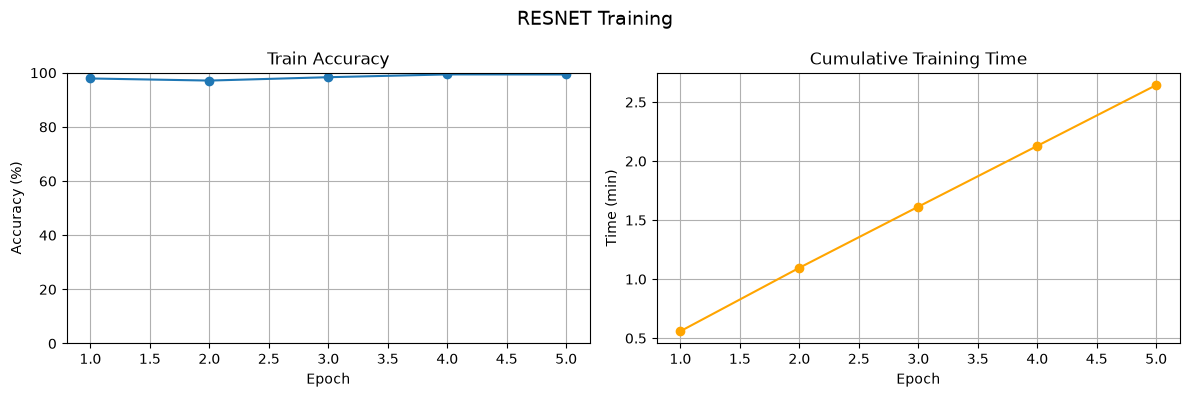

Model: cnn  |  Trainable parameters: 9,098
Epoch: 001/005 | Batch 0000/0469 | Cost: 2.3026
Epoch: 001/005 | Batch 0050/0469 | Cost: 0.9195
Epoch: 001/005 | Batch 0100/0469 | Cost: 0.6321
Epoch: 001/005 | Batch 0150/0469 | Cost: 0.3232
Epoch: 001/005 | Batch 0200/0469 | Cost: 0.4001
Epoch: 001/005 | Batch 0250/0469 | Cost: 0.2427
Epoch: 001/005 | Batch 0300/0469 | Cost: 0.2250
Epoch: 001/005 | Batch 0350/0469 | Cost: 0.1964
Epoch: 001/005 | Batch 0400/0469 | Cost: 0.2910
Epoch: 001/005 | Batch 0450/0469 | Cost: 0.1203
Epoch: 001/005 | Train Acc: 94.540%
Time elapsed: 0.07 min
Epoch: 002/005 | Batch 0000/0469 | Cost: 0.1826
Epoch: 002/005 | Batch 0050/0469 | Cost: 0.2442
Epoch: 002/005 | Batch 0100/0469 | Cost: 0.1074
Epoch: 002/005 | Batch 0150/0469 | Cost: 0.1897
Epoch: 002/005 | Batch 0200/0469 | Cost: 0.1681
Epoch: 002/005 | Batch 0250/0469 | Cost: 0.2466
Epoch: 002/005 | Batch 0300/0469 | Cost: 0.0859
Epoch: 002/005 | Batch 0350/0469 | Cost: 0.0953
Epoch: 002/005 | Batch 0400/0469 |

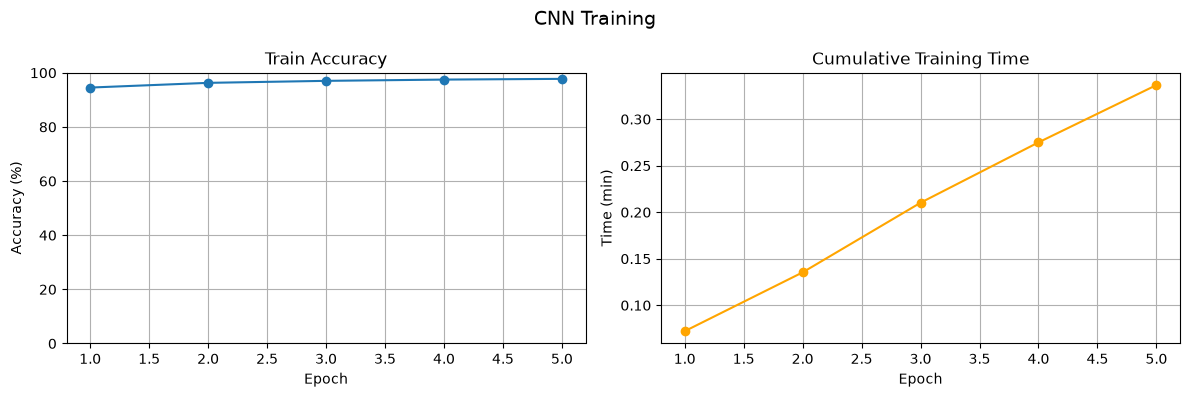

Model: mlp  |  Trainable parameters: 109,386
Epoch: 001/005 | Batch 0000/0469 | Cost: 2.3027
Epoch: 001/005 | Batch 0050/0469 | Cost: 0.9886
Epoch: 001/005 | Batch 0100/0469 | Cost: 0.7386
Epoch: 001/005 | Batch 0150/0469 | Cost: 0.5988
Epoch: 001/005 | Batch 0200/0469 | Cost: 0.3822
Epoch: 001/005 | Batch 0250/0469 | Cost: 0.4265
Epoch: 001/005 | Batch 0300/0469 | Cost: 0.3524
Epoch: 001/005 | Batch 0350/0469 | Cost: 0.3882
Epoch: 001/005 | Batch 0400/0469 | Cost: 0.3165
Epoch: 001/005 | Batch 0450/0469 | Cost: 0.2983
Epoch: 001/005 | Train Acc: 91.460%
Time elapsed: 0.06 min
Epoch: 002/005 | Batch 0000/0469 | Cost: 0.2905
Epoch: 002/005 | Batch 0050/0469 | Cost: 0.4040
Epoch: 002/005 | Batch 0100/0469 | Cost: 0.2332
Epoch: 002/005 | Batch 0150/0469 | Cost: 0.3045
Epoch: 002/005 | Batch 0200/0469 | Cost: 0.2196
Epoch: 002/005 | Batch 0250/0469 | Cost: 0.3507
Epoch: 002/005 | Batch 0300/0469 | Cost: 0.2224
Epoch: 002/005 | Batch 0350/0469 | Cost: 0.1953
Epoch: 002/005 | Batch 0400/0469

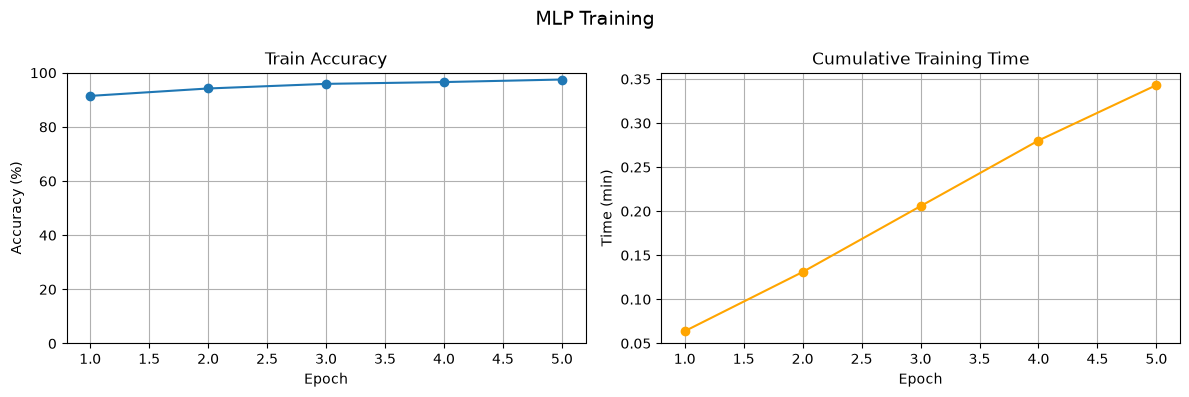

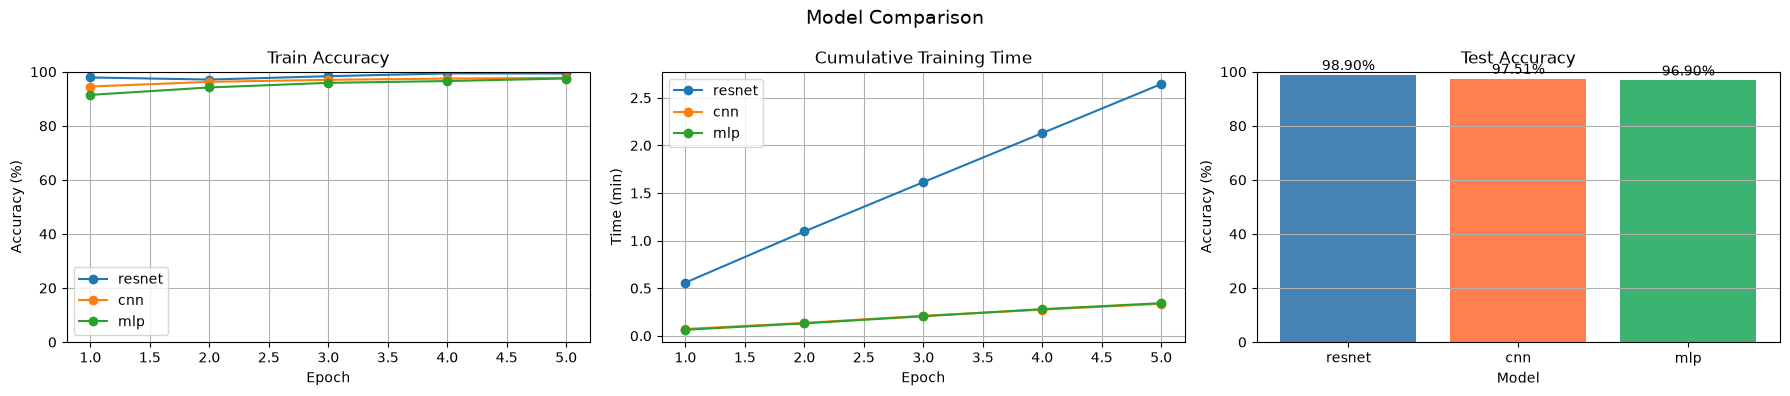

In [10]:
model_types = ['resnet', 'cnn', 'mlp']

all_results = {}

for model_type in model_types:
    tot_epoch = []
    accuracy = []
    tot_time = []
    MODEL_TYPE = model_type

    if MODEL_TYPE == 'resnet':
        model = resnet18(NUM_CLASSES)
    elif MODEL_TYPE == 'node':
        model = ODENet(num_classes=NUM_CLASSES)
    elif MODEL_TYPE == 'cnn':
        model = ConvNet(num_classes=NUM_CLASSES)
    elif MODEL_TYPE == 'mlp':
        model = MLP(num_features=NUM_FEATURES, num_classes=NUM_CLASSES)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {MODEL_TYPE}  |  Trainable parameters: {total_params:,}")

    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        tot_epoch.append(epoch + 1)
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            logits, probas = model(features)
            cost = F.cross_entropy(logits, targets)
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            if not batch_idx % 50:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                      % (epoch + 1, NUM_EPOCHS, batch_idx, len(train_loader), cost))

        model.eval()
        with torch.set_grad_enabled(False):
            train_acc = compute_accuracy(model, train_loader, device=DEVICE)
            print('Epoch: %03d/%03d | Train Acc: %.3f%%' % (epoch + 1, NUM_EPOCHS, train_acc))

        accuracy.append(train_acc.item())

        elapsed = (time.time() - start_time) / 60
        print('Time elapsed: %.2f min' % elapsed)
        tot_time.append(elapsed)

    print('Total Training Time: %.2f min' % ((time.time() - start_time) / 60))

    with torch.set_grad_enabled(False):
        test_acc = compute_accuracy(model, test_loader, device=DEVICE)
    print(f'[{MODEL_TYPE.upper()}] Test accuracy: {test_acc:.2f}%')

    all_results[MODEL_TYPE] = {
        'epochs': tot_epoch,
        'accuracy': accuracy,
        'time': tot_time,
        'test_accuracy': test_acc.item()  
    }

    # --- Per-model plots ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{MODEL_TYPE.upper()} Training', fontsize=14)

    axes[0].plot(tot_epoch, accuracy, marker='o')
    axes[0].set_title('Train Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_ylim(0, 100)
    axes[0].grid(True)

    axes[1].plot(tot_epoch, tot_time, marker='o', color='orange')
    axes[1].set_title('Cumulative Training Time')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Time (min)')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# --- Cross-model comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Model Comparison', fontsize=14)

for name, results in all_results.items():
    axes[0].plot(results['epochs'], results['accuracy'], marker='o', label=name)
    axes[1].plot(results['epochs'], results['time'], marker='o', label=name)

axes[0].set_title('Train Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Cumulative Training Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Time (min)')
axes[1].legend()
axes[1].grid(True)

# --- Test accuracy bar chart ---
names = list(all_results.keys())
test_accs = [all_results[name]['test_accuracy'] for name in names]

bars = axes[2].bar(names, test_accs, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[2].set_title('Test Accuracy')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(True, axis='y')
for bar, acc in zip(bars, test_accs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## node

In [11]:
from node_lib import ode_solve, ODEF, ODEAdjoint, NeuralODE

#### initializing n-ode for mnist

In [12]:
def norm(dim):
    return nn.BatchNorm2d(dim)

def conv3x3(in_feats, out_feats, stride=1):
    return nn.Conv2d(in_feats, out_feats, kernel_size=3, stride=stride, padding=1, bias=False)

def add_time(in_tensor, t):
    bs, c, w, h = in_tensor.shape
    return torch.cat((in_tensor, t.expand(bs, 1, w, h)), dim=1)

In [13]:
class ConvODEF(ODEF):
    def __init__(self, dim):
        super(ConvODEF, self).__init__()
        self.conv1 = conv3x3(dim + 1, dim)
        self.norm1 = norm(dim)
        self.conv2 = conv3x3(dim + 1, dim)
        self.norm2 = norm(dim)

    def forward(self, x, t):
        xt = add_time(x, t)
        h = self.norm1(torch.relu(self.conv1(xt)))
        ht = add_time(h, t)
        dxdt = self.norm2(torch.relu(self.conv2(ht)))
        return dxdt

In [14]:
class ContinuousNeuralMNISTClassifier(nn.Module):
    def __init__(self, ode):
        super(ContinuousNeuralMNISTClassifier, self).__init__()
        self.downsampling = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1),
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),
        )
        self.feature = ode
        self.norm = norm(64)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.downsampling(x)
        x = self.feature(x)
        x = self.norm(x)
        x = self.avg_pool(x)
        shape = torch.prod(torch.tensor(x.shape[1:])).item()
        x = x.view(-1, shape)
        out = self.fc(x)
        return out

In [15]:
func = ConvODEF(64)
ode = NeuralODE(func)
model = ContinuousNeuralMNISTClassifier(ode)
model = model.to(DEVICE)

In [16]:
optimizer = torch.optim.Adam(model.parameters())

#### train and test for mnist

In [17]:
optimizer = torch.optim.Adam(model.parameters())

In [18]:
def train(epoch):
    num_items = 0
    train_losses = []

    model.train()
    criterion = nn.CrossEntropyLoss()
    print(f"Training Epoch {epoch}...")
    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data = data.to(DEVICE)
        target = target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target) 
        loss.backward()
        optimizer.step()

        train_losses += [loss.item()]
        num_items += data.shape[0]
    print('Train loss: {:.5f}'.format(np.mean(train_losses)))
    return train_losses

In [19]:
def test():
    accuracy = 0.0
    num_items = 0

    model.eval()
    criterion = nn.CrossEntropyLoss()
    print(f"Testing...")
    with torch.no_grad():
        for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):
            data = data.to(DEVICE)
            target = target.to(DEVICE)
            output = model(data)
            accuracy += torch.sum(torch.argmax(output, dim=1) == target).item()
            num_items += data.shape[0]
    accuracy = accuracy * 100 / num_items
    print("Test Accuracy: {:.3f}%".format(accuracy))
    return accuracy

In [ ]:
n_epochs = 5
test()
train_losses = []
tot_time_node = []
for epoch in range(1, n_epochs + 1):
    start_time = time.time()
    train_losses += train(epoch)
    test_acc = test()
    end_time = time.time()-start_time
    tot_time_node.append(end_time)

Testing...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_60216/1405364119.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 9.580%
Training Epoch 1...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_60216/1238388639.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):


...

  0%|          | 0/469 [00:00<?, ?it/s]

Train loss: 0.03509
Testing...


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 98.810%
Training Epoch 4...


  0%|          | 0/469 [00:00<?, ?it/s]

In [ ]:
all_results['node'] = {
    'epochs': tot_epoch,
    'time': tot_time_node,
    'test_accuracy': test_acc  
}

In [ ]:
all_results

{'resnet': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [97.89833068847656,
   97.1199951171875,
   98.36500549316406,
   99.39167022705078,
   99.375],
  'time': [0.5628973325093587,
   1.1010069489479064,
   1.6374915997187296,
   2.1647133668263754,
   2.704311649004618],
  'test_accuracy': 98.9000015258789},
 'cnn': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [94.54000091552734,
   96.27833557128906,
   97.0183334350586,
   97.48500061035156,
   97.7550048828125],
  'time': [0.07432393630345663,
   0.14286230405171713,
   0.2114742358525594,
   0.27942805290222167,
   0.3463449875513713],
  'test_accuracy': 97.50999450683594},
 'mlp': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [91.45999908447266,
   94.19999694824219,
   95.90499877929688,
   96.56999969482422,
   97.51166534423828],
  'time': [0.06411868731180827,
   0.12838325500488282,
   0.1910340706507365,
   0.253875199953715,
   0.3173368175824483],
  'test_accuracy': 96.9000015258789},
 'node': {'epochs': [1, 2, 3, 4, 5],
  'time

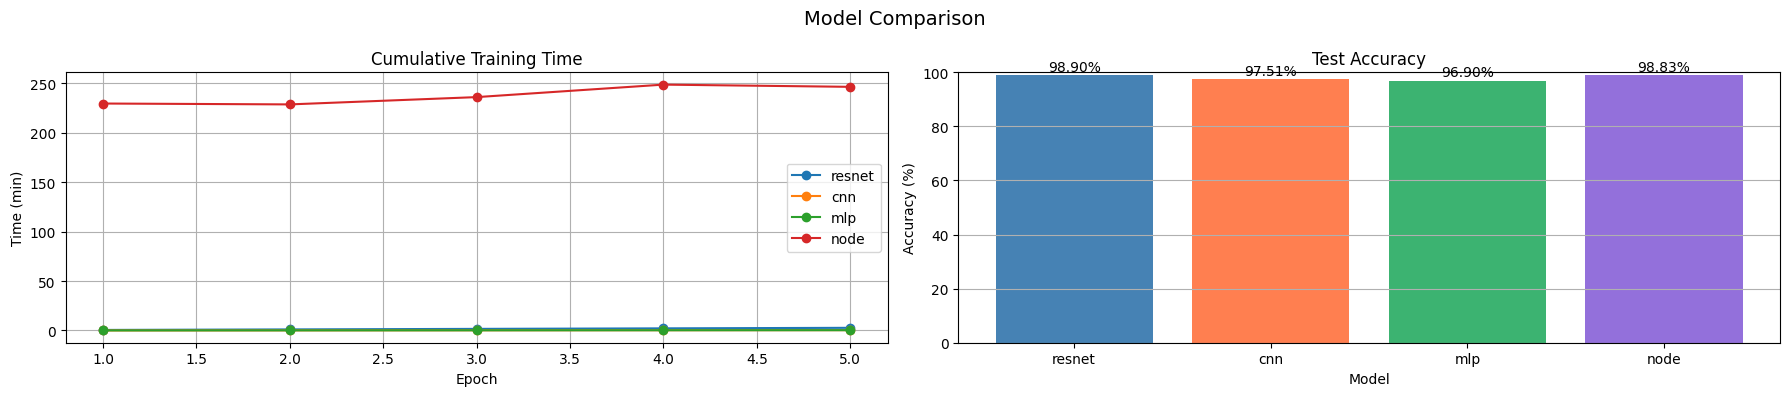

In [ ]:
# --- Cross-model comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle('Model Comparison', fontsize=14)

for name, results in all_results.items():
    #axes[0].plot(results['epochs'], results['accuracy'], marker='o', label=name)
    axes[0].plot(results['epochs'], results['time'], marker='o', label=name)

# axes[0].set_title('Train Accuracy')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy (%)')
# axes[0].set_ylim(0, 100)
# axes[0].legend()
# axes[0].grid(True)

axes[0].set_title('Cumulative Training Time')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Time (min)')
axes[0].legend()
axes[0].grid(True)

# --- Test accuracy bar chart ---
names = list(all_results.keys())
test_accs = [all_results[name]['test_accuracy'] for name in names]

bars = axes[1].bar(names, test_accs, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(True, axis='y')
for bar, acc in zip(bars, test_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()